# LSTM on mnist dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/10.S RNN & LSTM/RNN - LSTM - GRU

/content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/10.S RNN & LSTM/RNN - LSTM - GRU


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

In [ ]:
mnist = tf.keras.datasets.mnist  # mnist is a dataset of 28x28 images of handwritten digits and their labels
(x_train, y_train),(x_test, y_test) = mnist.load_data()  # unpacks images to x_train/x_test and labels to y_train/y_test

x_train = x_train/255.0
x_test = x_test/255.0

print(x_train.shape)
print(x_train[0].shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(28, 28)


In [ ]:
x_train.shape[1:]

(28, 28)

In [ ]:
model = Sequential()
model.add(LSTM(128, input_shape=(x_train.shape[1:]), activation='relu', return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


The `return_sequences=True` in the LSTM layer makes the LSTM return the output at each timestep, preserving the full sequence. This is useful for:

1. Stacking multiple LSTM layers, as the next LSTM layer expects the full sequence.
2. Tasks where you need predictions or outputs for every timestep (e.g., time series, speech recognition).

Without `return_sequences=True`, the LSTM would only return the output at the last timestep.

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001, decay=1e-6)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy'],
)

history = model.fit(x_train,
          y_train,
          epochs=10,
          validation_data=(x_test, y_test))

/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.6543 - loss: 1.0144 - val_accuracy: 0.9163 - val_loss: 0.3098
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - accuracy: 0.9494 - loss: 0.1853 - val_accuracy: 0.9759 - val_loss: 0.0857
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9711 - loss: 0.1095 - val_accuracy: 0.9796 - val_loss: 0.0713
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9785 - loss: 0.0805 - val_accuracy: 0.9798 - val_loss: 0.0829
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9823 - loss: 0.0678 - val_accuracy: 0.9854 - val_loss: 0.0512
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9831 - loss: 0.0624 - val_accuracy: 0.9872 - val_loss: 0.0470
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9861 - loss: 0.0563 - val_accuracy: 0.9819 - val_loss: 0.0654
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9843 -

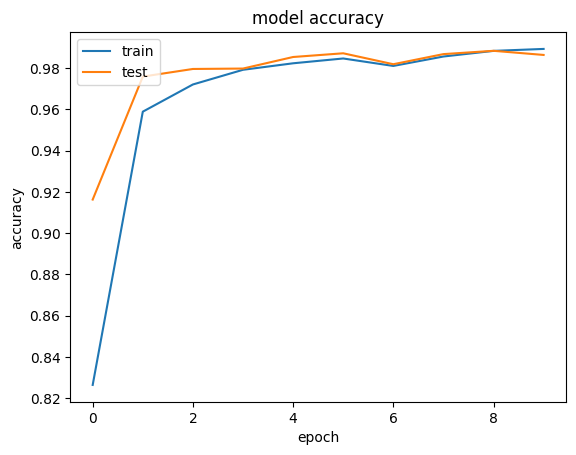

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

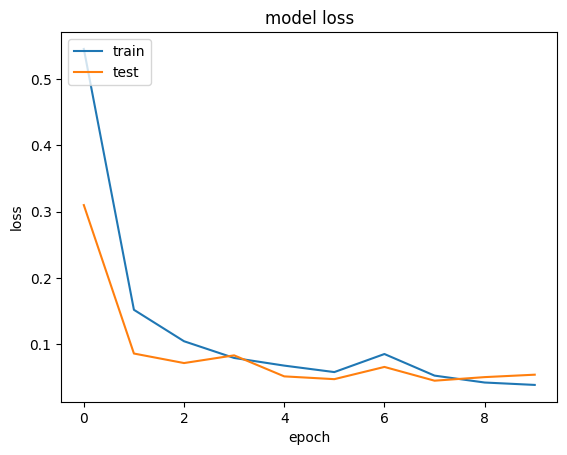

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
